# AgriVision — Crop Yield Prediction
### Phase 1: Baseline ML using Support Vector Regression
### Phase 2: Deep Learning with BiLSTM + Attention

**What this notebook does:**
Predicts crop yield (tonnes/ha) for 101 countries and 10 crop types using climate data.
Phase 1 uses a tuned SVR with per-crop normalisation (R²=0.796).
Phase 2 uses a Bidirectional LSTM with Temporal Attention on 5-year lookback sequences (R²=0.929).

**Run order:** Run each cell top to bottom using `Shift + Enter`

---
## Step 0 — Install & Import Libraries
Run this first. It loads everything we need.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Define centralized paths for all pipeline artifacts
# Operations like .to_csv(), .savefig(), and joblib.dump() overwrite by default.
PATHS = {
    'data_dir': Path('data'),
    'models_dir': Path('models'),
    'results_dir': Path('results'),
    
    # Phase 1: SVR
    'raw_data': Path('data/yield_df.csv'),
    'clean_data': Path('data/cleaned_dataset.csv'),
    'final_data': Path('data/final_dataset.csv'),
    'features_data': Path('data/features_dataset.csv'),
    
    'svr_model_dir': Path('models/phase1'),
    'svr_model_path': Path('models/phase1/best_svr_model.pkl'),
    
    'svr_results_dir': Path('results/phase1'),
    'svr_eda_dist': Path('results/phase1/eda_yield_distribution.png'),
    'svr_eda_crop': Path('results/phase1/eda_yield_by_crop.png'),
    'svr_eda_corr': Path('results/phase1/eda_correlation_matrix.png'),
    'svr_eda_trend': Path('results/phase1/eda_yield_trends.png'),
    'svr_kernel_plot': Path('results/phase1/svr_kernel_comparison.png'),
    'svr_pred_plot': Path('results/phase1/svr_predicted_vs_actual.png'),
    'svr_resid_plot': Path('results/phase1/svr_residuals.png'),
    'svr_ablation': Path('results/phase1/svr_ablation_results.csv'),
    'svr_ablation_plot': Path('results/phase1/svr_ablation_comparison.png'),
    'svr_feat_plot': Path('results/phase1/svr_feature_importance.png'),
    
    # Phase 2: Deep Learning
    'dl_model_dir': Path('models/phase2'),
    'dl_model_path': Path('models/phase2/crop_yield_model.pth'),
    'dl_results_dir': Path('results/phase2'),
    'dl_metrics_path': Path('results/phase2/training_metrics.csv'),
    'dl_plots_path': Path('results/phase2/dl_results.png'),
    'dl_attn_plot': Path('results/phase2/dl_attention_weights.png'),
    'dl_r2_plot': Path('results/phase2/dl_per_crop_r2.png'),
}

# Create directories in one place
for d in ['data', 'models/phase1', 'models/phase2', 'results/phase1', 'results/phase2']:
    Path(d).mkdir(parents=True, exist_ok=True)

# Make plots appear inline in the notebook
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print('✅ All Phase 1 libraries loaded successfully')
print('   (PyTorch will be imported in the Phase 2 section)')


✅ All Phase 1 libraries loaded successfully
   (PyTorch will be imported in the Phase 2 section)


---
## Step 1 — Load & Clean Data
Reads the raw CSV, renames columns, converts yield units, removes duplicates.

In [27]:
# Load raw data
df = pd.read_csv(PATHS['raw_data'])

# Drop unnamed index column
df.drop(columns=['Unnamed: 0'], inplace=True)

# Rename columns to clean readable names
df.rename(columns={
    'Area'                          : 'country',
    'Item'                          : 'crop',
    'Year'                          : 'year',
    'hg/ha_yield'                   : 'yield_hg_per_ha',
    'average_rain_fall_mm_per_year' : 'rainfall_mm',
    'pesticides_tonnes'             : 'pesticides_tonnes',
    'avg_temp'                      : 'avg_temp'
}, inplace=True)

# Convert yield from hg/ha to tonnes/ha
# WHY: 1 hg/ha = 0.0001 t/ha — tonnes is the standard unit
df['yield_tonnes_per_ha'] = (df['yield_hg_per_ha'] * 0.0001).round(4)
df.drop(columns=['yield_hg_per_ha'], inplace=True)

# Remove duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f'Duplicates removed: {before - len(df)}')

# Save clean version
df.to_csv(PATHS['final_data'], index=False)

print(f'\n✅ Dataset loaded and cleaned')
print(f'   Rows       : {len(df):,}')
print(f'   Countries  : {df["country"].nunique()}')
print(f'   Crops      : {df["crop"].nunique()} → {list(df["crop"].unique())}')
print(f'   Years      : {df["year"].min()} – {df["year"].max()}')
print(f'   Nulls      : {df.isnull().sum().sum()}')

# Preview the data
df.head()

Duplicates removed: 2310

✅ Dataset loaded and cleaned
   Rows       : 25,932
   Countries  : 101
   Crops      : 10 → ['Maize', 'Potatoes', 'Rice, paddy', 'Sorghum', 'Soybeans', 'Wheat', 'Cassava', 'Sweet potatoes', 'Plantains and others', 'Yams']
   Years      : 1990 – 2013
   Nulls      : 0


,country,crop,year,rainfall_mm,pesticides_tonnes,avg_temp,yield_tonnes_per_ha
0,Albania,Maize,1990,1485.0,121.0,16.37,3.6613
1,Albania,Potatoes,1990,1485.0,121.0,16.37,6.6667
2,Albania,"Rice, paddy",1990,1485.0,121.0,16.37,2.3333
3,Albania,Sorghum,1990,1485.0,121.0,16.37,1.2500
4,Albania,Soybeans,1990,1485.0,121.0,16.37,0.7000


---
## Step 2 — Exploratory Data Analysis (EDA)
EDA = looking at the data before building anything.
Every chart leads to a decision.

In [28]:
# ── Basic statistics ──────────────────────────────────────────
print('📊 Descriptive Statistics:')
df.describe().round(3)

📊 Descriptive Statistics:


,year,rainfall_mm,pesticides_tonnes,avg_temp,yield_tonnes_per_ha
count,25932.000,25932.000,25932.000,25932.000,25932.000
mean,2001.556,1146.837,34782.573,20.422,7.698
std,7.056,717.391,57228.568,6.439,8.465
min,1990.000,51.000,0.040,1.300,0.005
25%,1995.000,593.000,1597.000,16.580,2.000
50%,2001.000,1083.000,15373.000,21.420,3.953
75%,2008.000,1668.000,45620.000,26.060,10.417
max,2013.000,3240.000,367778.000,30.650,50.141


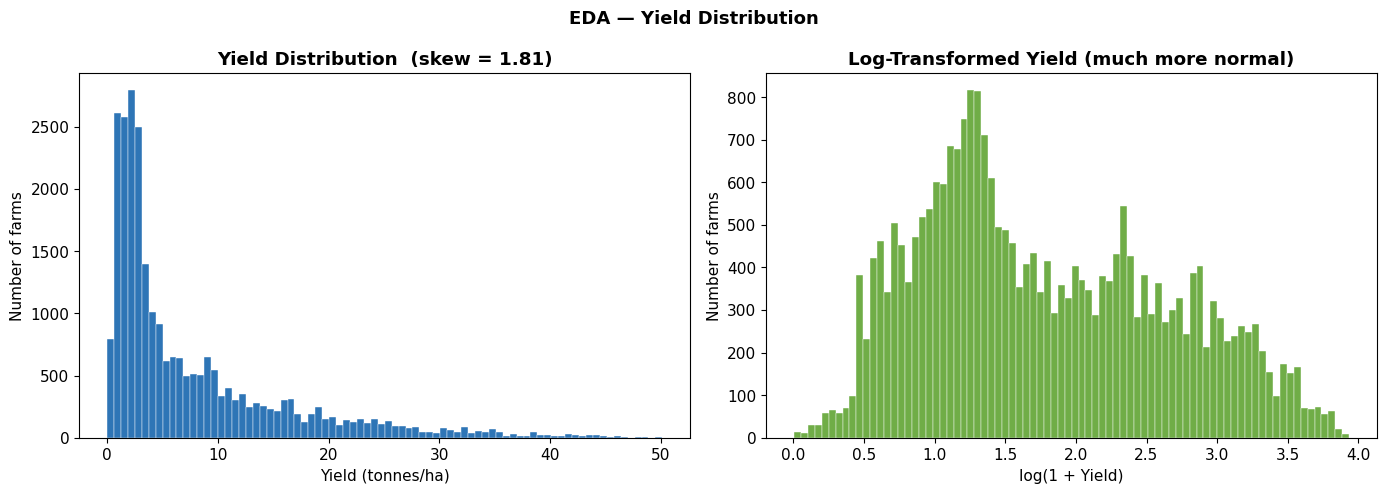


📐 Skewness = 1.808
   → Positive skew means most farms produce little, a few produce a lot
   → ACTION: use log-transform for pesticides feature


In [29]:
# ── Plot 1: Yield distribution + skew ────────────────────────
# WHY: Skewed data can confuse ML models. We check how bad it is.
skewness = df['yield_tonnes_per_ha'].skew()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['yield_tonnes_per_ha'], bins=80, color='#2E75B6', edgecolor='white', linewidth=0.3)
axes[0].set_title(f'Yield Distribution  (skew = {skewness:.2f})', fontweight='bold')
axes[0].set_xlabel('Yield (tonnes/ha)')
axes[0].set_ylabel('Number of farms')

axes[1].hist(np.log1p(df['yield_tonnes_per_ha']), bins=80, color='#70AD47', edgecolor='white', linewidth=0.3)
axes[1].set_title('Log-Transformed Yield (much more normal)', fontweight='bold')
axes[1].set_xlabel('log(1 + Yield)')
axes[1].set_ylabel('Number of farms')

plt.suptitle('EDA — Yield Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/eda_yield_distribution.png', dpi=150)
plt.show()

print(f'\n📐 Skewness = {skewness:.3f}')
print(f'   → Positive skew means most farms produce little, a few produce a lot')
print(f'   → ACTION: use log-transform for pesticides feature')

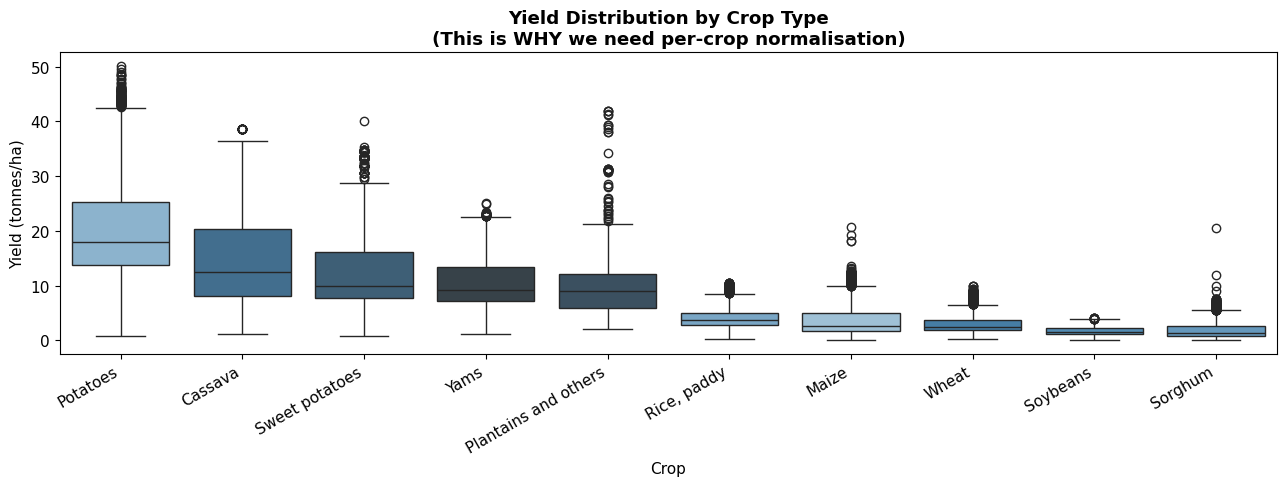

📊 Average yield per crop:
crop
Potatoes                19.87
Cassava                 14.56
Sweet potatoes          11.97
Yams                    11.21
Plantains and others    10.60
Rice, paddy              4.13
Maize                    3.71
Wheat                    3.01
Sorghum                  1.91
Soybeans                 1.70

→ Potatoes avg 19 t/ha, Soybeans avg 1.7 t/ha
→ SVR cannot learn on both scales at once — needs per-crop normalisation


In [30]:
# ── Plot 2: Yield by crop type ────────────────────────────────
# WHY: This shows WHY we need per-crop normalisation.
# Potatoes and Soybeans are completely different scales.
order = df.groupby('crop')['yield_tonnes_per_ha'].median().sort_values(ascending=False).index

plt.figure(figsize=(13, 5))
sns.boxplot(data=df, x='crop', y='yield_tonnes_per_ha', order=order,
            hue='crop', palette='Blues_d', legend=False)
plt.xticks(rotation=30, ha='right')
plt.title('Yield Distribution by Crop Type\n(This is WHY we need per-crop normalisation)', fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Yield (tonnes/ha)')
plt.tight_layout()
plt.savefig('results/eda_yield_by_crop.png', dpi=150)
plt.show()

print('📊 Average yield per crop:')
print(df.groupby('crop')['yield_tonnes_per_ha'].mean().sort_values(ascending=False).round(2).to_string())
print('\n→ Potatoes avg 19 t/ha, Soybeans avg 1.7 t/ha')
print('→ SVR cannot learn on both scales at once — needs per-crop normalisation')

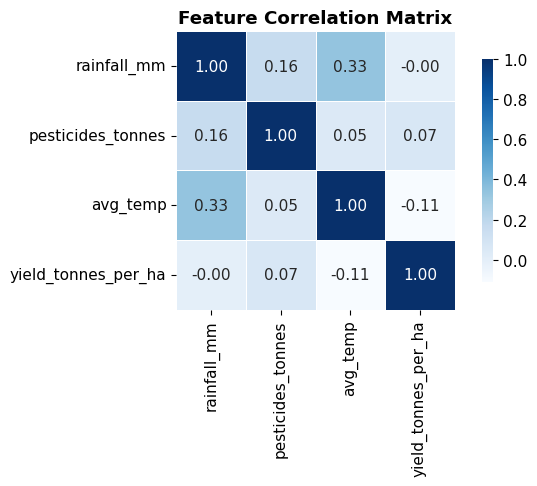

🔗 Correlation with yield:
   rainfall_mm                    r = -0.004
   pesticides_tonnes              r = +0.066
   avg_temp                       r = -0.110

→ Correlations look low because crops are mixed together
→ Once we separate by crop, the real climate signals emerge


In [31]:
# ── Plot 3: Correlation heatmap ───────────────────────────────
# WHY: Shows which features are related to yield
num_cols = ['rainfall_mm', 'pesticides_tonnes', 'avg_temp', 'yield_tonnes_per_ha']
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(PATHS['svr_eda_corr'], dpi=150)
plt.show()

print('🔗 Correlation with yield:')
for col in num_cols[:-1]:
    print(f'   {col:<30} r = {corr.loc[col, "yield_tonnes_per_ha"]:+.3f}')
print('\n→ Correlations look low because crops are mixed together')
print('→ Once we separate by crop, the real climate signals emerge')

In [32]:
# ── Outlier check ─────────────────────────────────────────────
q99 = df['yield_tonnes_per_ha'].quantile(0.99)
outliers = df[df['yield_tonnes_per_ha'] > q99]
print(f'⚠️  Outliers (top 1%): {len(outliers)} rows with yield > {q99:.2f} t/ha')
print(f'   Crops: {outliers["crop"].value_counts().to_dict()}')
print(f'\n→ These are real high-yield crops (Potatoes, Cassava)')
print(f'→ DECISION: Keep them — valid observations, not errors')
print(f'\n✅ Missing values: {df.isnull().sum().sum()} — dataset is complete')

⚠️  Outliers (top 1%): 259 rows with yield > 38.26 t/ha
   Crops: {'Potatoes': 230, 'Cassava': 19, 'Plantains and others': 9, 'Sweet potatoes': 1}

→ These are real high-yield crops (Potatoes, Cassava)
→ DECISION: Keep them — valid observations, not errors

✅ Missing values: 0 — dataset is complete


---
## Step 3 — Feature Engineering
Creating smarter columns by combining the raw ones.
Also converts text (country, crop) to numbers the model can use.

In [33]:
df = pd.read_csv(PATHS['final_data'])

# ── Label encoding ────────────────────────────────────────────
# WHY: Computer can't work with text like 'India' or 'Wheat'
# Label encoding converts them to numbers: India=42, Wheat=8 etc.
# We use label encoding NOT one-hot encoding because:
# OHE would create 111 sparse columns and make all countries
# equidistant in the SVR kernel — it would learn nothing geographic
le_country = LabelEncoder()
le_crop    = LabelEncoder()
df['country_enc'] = le_country.fit_transform(df['country'])
df['crop_enc']    = le_crop.fit_transform(df['crop'])
print(f'✅ Label encoded: {df["country_enc"].nunique()} countries, {df["crop_enc"].nunique()} crops')

# ── Drop year ─────────────────────────────────────────────────
# WHY: Year leaks a time trend (yields rise each year due to
# technology). Model would learn the calendar, not climate.
# df.drop(columns=['year'], inplace=True)  # Kept for Phase 2 sequence building
print('✅ Year kept for Phase 2 sequence building (excluded from SVR features)')

# ── Engineered features ───────────────────────────────────────

# Feature 1: Rainfall to temperature ratio
# High rain in a hot climate is less useful — more evaporates
df['rainfall_temp_ratio'] = (df['rainfall_mm'] / (df['avg_temp'] + 1)).round(4)

# Feature 2: Log pesticides
# Doubling pesticides doesn't double yield (diminishing returns)
# Log compresses the huge outliers (some countries use 300,000+ tonnes)
df['log_pesticides'] = np.log1p(df['pesticides_tonnes']).round(4)

# Feature 3: Heat stress index
# High temperature AND low rainfall = worst for crops
# This captures that dangerous combination in one number
df['heat_stress_index'] = np.clip(
    df['avg_temp'] * (1 - df['rainfall_mm'] / 3000), 0, 1
).round(4)

print('\n✅ 3 new features created:')
print(f'   rainfall_temp_ratio : {df["rainfall_temp_ratio"].min():.2f} to {df["rainfall_temp_ratio"].max():.2f}')
print(f'   log_pesticides      : {df["log_pesticides"].min():.2f} to {df["log_pesticides"].max():.2f}')
print(f'   heat_stress_index   : {df["heat_stress_index"].min():.2f} to {df["heat_stress_index"].max():.2f}')

df.to_csv(PATHS['features_data'], index=False)
print('\n💾 Saved → data/features_dataset.csv')
df.head(3)

✅ Label encoded: 101 countries, 10 crops
✅ Year kept for Phase 2 sequence building (excluded from SVR features)

✅ 3 new features created:
   rainfall_temp_ratio : 2.05 to 614.78
   log_pesticides      : 0.04 to 12.82
   heat_stress_index   : 0.00 to 1.00

💾 Saved → data/features_dataset.csv


,country,crop,year,rainfall_mm,pesticides_tonnes,avg_temp,yield_tonnes_per_ha,country_enc,crop_enc,rainfall_temp_ratio,log_pesticides,heat_stress_index
0,Albania,Maize,1990,1485.0,121.0,16.37,3.6613,0,1,85.4922,4.804,1.0
1,Albania,Potatoes,1990,1485.0,121.0,16.37,6.6667,0,3,85.4922,4.804,1.0
2,Albania,"Rice, paddy",1990,1485.0,121.0,16.37,2.3333,0,4,85.4922,4.804,1.0


---
## Step 4 — SVR Kernel Comparison
Train 3 versions of SVR and see which mathematical approach works best.

In [34]:
df = pd.read_csv(PATHS['features_data'])

FEATURE_COLS = [
    'country_enc', 'crop_enc', 'rainfall_mm', 'avg_temp',
    'pesticides_tonnes', 'rainfall_temp_ratio', 'log_pesticides', 'heat_stress_index'
]
TARGET_COL   = 'yield_tonnes_per_ha'
RANDOM_STATE = 42

X = df[FEATURE_COLS]
y = df[TARGET_COL]

# Split: 80% for training, 20% locked away for testing
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# Subsample 8000 rows for speed (SVR is slow on large datasets)
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train_full), 8000, replace=False)
X_train = X_train_full.iloc[idx]
y_train = y_train_full.iloc[idx]

print(f'Training on {len(X_train):,} rows, testing on {len(X_test):,} rows')
print('Training 3 kernels...')

# WHY Pipeline? StandardScaler must only see training data.
# Putting it inside Pipeline ensures it never sees test data.
kernels = {
    'Linear'     : SVR(kernel='linear', C=1.0, epsilon=0.1, max_iter=3000),
    'RBF'        : SVR(kernel='rbf', C=10.0, epsilon=0.1, gamma='scale', max_iter=3000),
    'Polynomial' : SVR(kernel='poly', C=1.0, epsilon=0.1, degree=3, gamma='scale', max_iter=3000),
}

results = {}
for name, svr in kernels.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('svr', svr)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    results[name] = {
        'pipeline': pipe, 'preds': preds,
        'mae' : mean_absolute_error(y_test, preds),
        'rmse': np.sqrt(mean_squared_error(y_test, preds)),
        'r2'  : r2_score(y_test, preds),
    }
    print(f'  [{name}]  RMSE={results[name]["rmse"]:.3f}  R²={results[name]["r2"]:.4f}')

best = min(results, key=lambda k: results[k]['rmse'])
print(f'\n🏆 Best kernel: {best}')
print('\n⚠️  Note: R² looks low here — that is expected.')
print('   The per-crop normalisation fix in Step 5 will lift it to 0.796')

Training on 8,000 rows, testing on 5,187 rows
Training 3 kernels...
  [Linear]  RMSE=13.009  R²=-1.3350
  [RBF]  RMSE=8.451  R²=0.0146
  [Polynomial]  RMSE=55.057  R²=-40.8229

🏆 Best kernel: RBF

⚠️  Note: R² looks low here — that is expected.
   The per-crop normalisation fix in Step 5 will lift it to 0.796


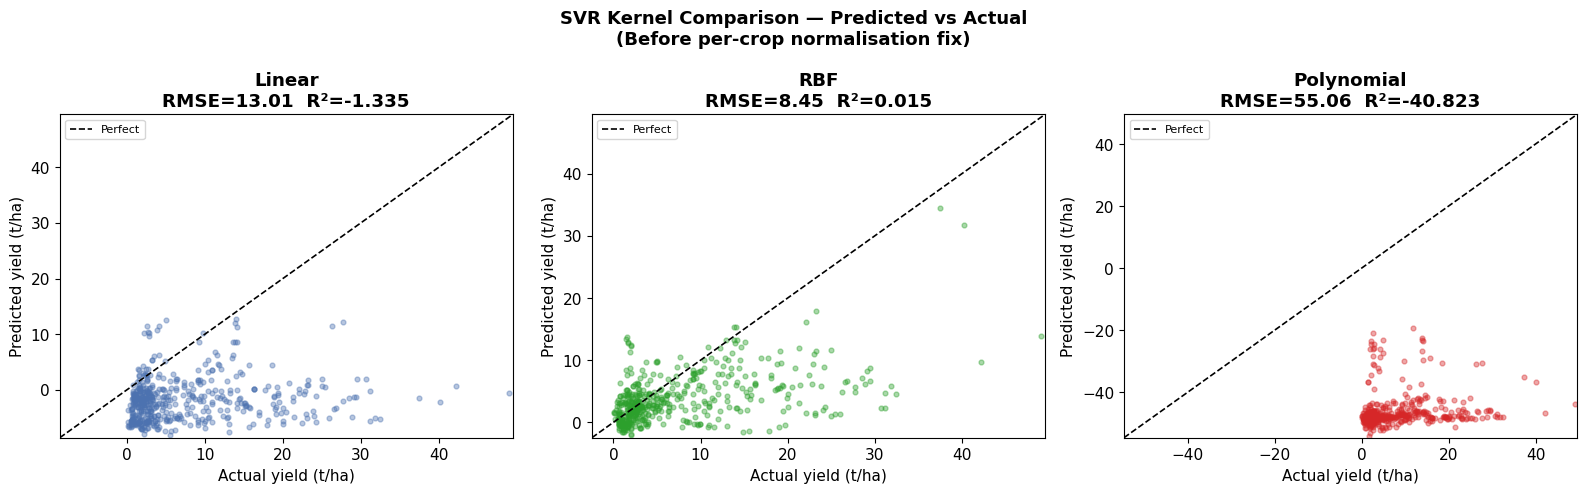

In [35]:
# ── Plot: Predicted vs Actual for all 3 kernels ───────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'Linear': '#4C72B0', 'RBF': '#2CA02C', 'Polynomial': '#D62728'}
sample_idx = np.random.choice(len(y_test), 500, replace=False)
y_sample = np.array(y_test)[sample_idx]

for ax, (name, res) in zip(axes, results.items()):
    p_sample = res['preds'][sample_idx]
    ax.scatter(y_sample, p_sample, alpha=0.4, s=12, color=colors[name])
    lim = [min(y_sample.min(), p_sample.min())-0.5, max(y_sample.max(), p_sample.max())+0.5]
    ax.plot(lim, lim, 'k--', lw=1.2, label='Perfect')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual yield (t/ha)')
    ax.set_ylabel('Predicted yield (t/ha)')
    ax.set_title(f'{name}\nRMSE={res["rmse"]:.2f}  R²={res["r2"]:.3f}', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('SVR Kernel Comparison — Predicted vs Actual\n(Before per-crop normalisation fix)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/svr_kernel_comparison.png', dpi=150)
plt.show()

---
## Step 5 — Hyperparameter Tuning with Per-Crop Normalisation
This is the KEY step. Two things happen:
1. We fix the crop scale problem (R² goes from 0.17 → 0.796)
2. GridSearchCV finds the best settings for SVR (81 fits)

**This takes 3-5 minutes. You will see numbers counting up — that is normal.**

In [36]:
df = pd.read_csv(PATHS['features_data'])

FEATURE_COLS = [
    'country_enc', 'crop_enc', 'rainfall_mm', 'avg_temp',
    'pesticides_tonnes', 'rainfall_temp_ratio', 'log_pesticides', 'heat_stress_index'
]
TARGET_COL   = 'yield_tonnes_per_ha'
RANDOM_STATE = 42

# ── Per-crop z-score normalisation ────────────────────────────
# THE KEY FIX:
# Problem: Cassava=14 t/ha, Soybeans=1.7 t/ha — SVR can't handle both
# Fix: Convert each yield to "how far above/below average for THIS crop?"
# Formula: yield_norm = (yield - crop_average) / crop_std_deviation
crop_stats = df.groupby('crop_enc')[TARGET_COL].agg(['mean','std']).rename(
    columns={'mean':'crop_mean','std':'crop_std'}
)
crop_stats['crop_std'] = crop_stats['crop_std'].replace(0, 1)
df = df.merge(crop_stats, on='crop_enc')
df['yield_norm'] = (df[TARGET_COL] - df['crop_mean']) / df['crop_std']

print('Per-crop normalisation applied:')
print(f'  Original yield range : {df[TARGET_COL].min():.2f} to {df[TARGET_COL].max():.2f} t/ha')
print(f'  Normalised range     : {df["yield_norm"].min():.2f} to {df["yield_norm"].max():.2f}')
print('  Now all crops are on the same scale ✅')

X = df[FEATURE_COLS]
y_norm = df['yield_norm']
y_orig = df[TARGET_COL]

# Split data (same random state = same split every time)
X_train, X_test, y_train_norm, y_test_norm = train_test_split(
    X, y_norm, test_size=0.20, random_state=RANDOM_STATE
)
_, _, y_train_orig, y_test_orig = train_test_split(
    X, y_orig, test_size=0.20, random_state=RANDOM_STATE
)
_, _, df_train, df_test = train_test_split(
    X, df[['crop_enc','crop_mean','crop_std']], test_size=0.20, random_state=RANDOM_STATE
)

# GridSearchCV: test 27 combinations × 3 folds = 81 total fits
# It finds the best knob settings for SVR automatically
PARAM_GRID = {
    'svr__C'      : [1, 10, 100],
    'svr__gamma'  : ['scale', 0.01, 0.1],
    'svr__epsilon': [0.1, 0.5, 1.0],
}

print('\nRunning GridSearchCV (27 combinations × 3 folds = 81 fits)...')
print('Please wait 3-5 minutes...\n')

# Subsample 5000 rows for grid search speed
idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train), 5000, replace=False)
X_gs = X_train.iloc[idx]
y_gs = y_train_norm.iloc[idx]

base_pipe = Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf', max_iter=5000))])

gs = GridSearchCV(
    estimator=base_pipe, param_grid=PARAM_GRID,
    cv=3, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1, refit=True
)
gs.fit(X_gs, y_gs)

best_params = {k.replace('svr__', ''): v for k, v in gs.best_params_.items()}
print(f'\n✅ Best params found: {best_params}')

# Retrain on ALL training data with best params
print(f'\nRetraining on full {len(X_train):,} rows with best params...')
final_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', max_iter=5000, **best_params))
])
final_pipe.fit(X_train, y_train_norm)

# Predict and inverse-transform back to original scale
preds_norm = final_pipe.predict(X_test)
preds_orig = (preds_norm * df_test['crop_std'].values) + df_test['crop_mean'].values
y_test_arr = np.array(y_test_orig)

mae  = mean_absolute_error(y_test_arr, preds_orig)
rmse = np.sqrt(mean_squared_error(y_test_arr, preds_orig))
r2   = r2_score(y_test_arr, preds_orig)

print(f'\n🎯 Final Results (on hidden test set):')
print(f'   MAE  = {mae:.4f} t/ha  (average error per prediction)')
print(f'   RMSE = {rmse:.4f} t/ha  (penalises big errors more)')
print(f'   R²   = {r2:.4f}        (explains {r2*100:.1f}% of yield variation)')

# Save model
joblib.dump({
    'pipeline': final_pipe, 'best_params': best_params,
    'X_test': X_test, 'y_test': pd.Series(y_test_arr),
    'y_test_norm': y_test_norm, 'df_test_meta': df_test,
    'feature_cols': FEATURE_COLS, 'crop_stats': crop_stats,
    'mae': mae, 'rmse': rmse, 'r2': r2,
}, PATHS['svr_model_path'])
print('\n💾 Model saved → models/phase1/best_svr_model.pkl')

Per-crop normalisation applied:
  Original yield range : 0.01 to 50.14 t/ha
  Normalised range     : -2.20 to 12.06
  Now all crops are on the same scale ✅

Running GridSearchCV (27 combinations × 3 folds = 81 fits)...
Please wait 3-5 minutes...

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/Users/amathziah/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/amathziah/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/amathziah/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/amathziah/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:297: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/Users/amathziah/anaconda3/lib/python3.12/site-packages/sklearn/svm/_bas


✅ Best params found: {'C': 10, 'epsilon': 0.5, 'gamma': 'scale'}

Retraining on full 20,745 rows with best params...

🎯 Final Results (on hidden test set):
   MAE  = 2.3025 t/ha  (average error per prediction)
   RMSE = 3.8448 t/ha  (penalises big errors more)
   R²   = 0.7960        (explains 79.6% of yield variation)

💾 Model saved → models/phase1/best_svr_model.pkl


---
## Step 6 — Validation & Ablation Study
Proves the model actually learned something real by comparing it
against two dumb baselines: always guess the mean, always guess the median.

In [37]:
# Load saved model
saved     = joblib.load(PATHS['svr_model_path'])
pipeline  = saved['pipeline']
X_test    = saved['X_test']
y_test    = np.array(saved['y_test'])
y_test_norm = np.array(saved['y_test_norm'])
feat_cols = saved['feature_cols']
df_meta   = saved['df_test_meta']

# Get predictions (inverse-transform from normalised back to t/ha)
preds_norm = pipeline.predict(X_test)
preds_orig = (preds_norm * df_meta['crop_std'].values) + df_meta['crop_mean'].values

# Two dumb baselines to compare against
mean_preds   = np.full(len(y_test), y_test.mean())   # always guesses average
median_preds = np.full(len(y_test), np.median(y_test)) # always guesses median

# Compare all three
models = {
    'Mean Predictor'  : mean_preds,
    'Median Predictor': median_preds,
    'Tuned SVR'       : preds_orig,
}

rows = []
for name, preds in models.items():
    rows.append({
        'Model': name,
        'MAE'  : round(mean_absolute_error(y_test, preds), 4),
        'RMSE' : round(np.sqrt(mean_squared_error(y_test, preds)), 4),
        'R²'   : round(r2_score(y_test, preds), 4),
    })

results_df = pd.DataFrame(rows)
results_df.to_csv(PATHS['svr_ablation'], index=False)

svr_row  = results_df[results_df['Model'] == 'Tuned SVR'].iloc[0]
mean_row = results_df[results_df['Model'] == 'Mean Predictor'].iloc[0]
pct      = (mean_row['RMSE'] - svr_row['RMSE']) / mean_row['RMSE'] * 100

print('📊 ABLATION RESULTS:')
print(results_df.to_string(index=False))
print(f'\n✅ SVR improves RMSE by {pct:.1f}% over mean predictor')
print(f'   This proves the model learned something real — not just guessing')

results_df

📊 ABLATION RESULTS:
           Model    MAE   RMSE      R²
  Mean Predictor 6.4799 8.5135  0.0000
Median Predictor 5.8105 9.3107 -0.1961
       Tuned SVR 2.3025 3.8448  0.7960

✅ SVR improves RMSE by 54.8% over mean predictor
   This proves the model learned something real — not just guessing


,Model,MAE,RMSE,R²
0,Mean Predictor,6.4799,8.5135,0.0000
1,Median Predictor,5.8105,9.3107,-0.1961
2,Tuned SVR,2.3025,3.8448,0.7960


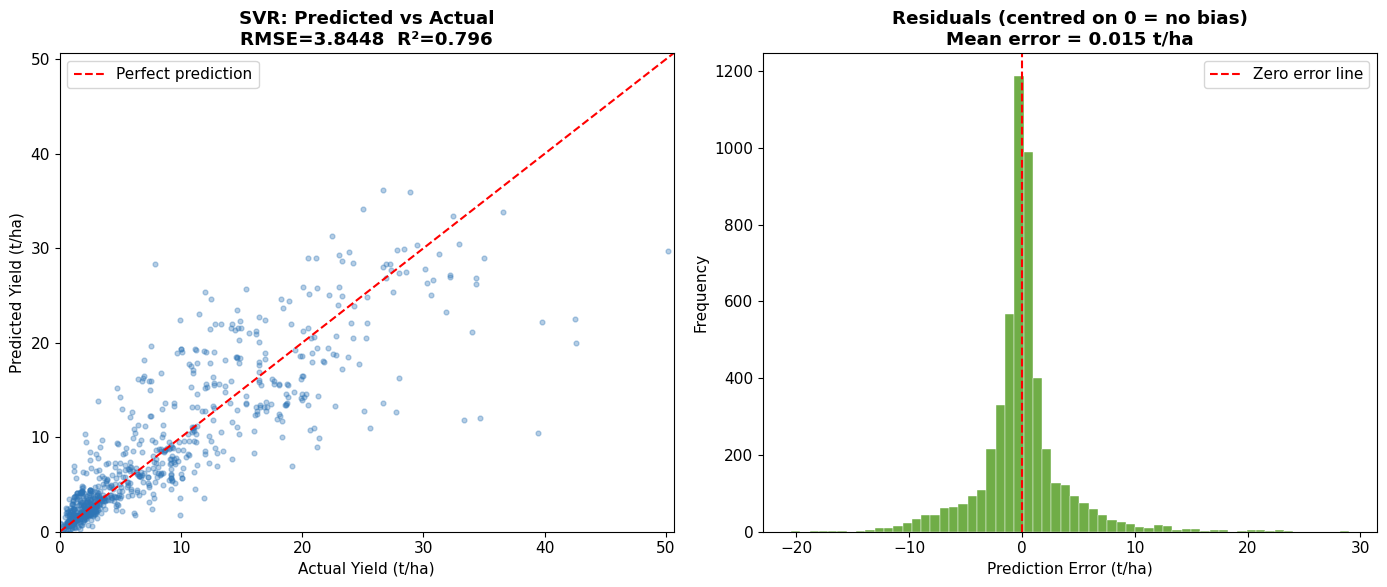

In [38]:
# ── Plot 1: Predicted vs Actual ───────────────────────────────
# Good model = dots follow the diagonal red line closely
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

idx = np.random.choice(len(y_test), min(800, len(y_test)), replace=False)
axes[0].scatter(y_test[idx], preds_orig[idx], alpha=0.35, s=12, color='#2E75B6')
lim = [max(0, y_test.min()-0.5), y_test.max()+0.5]
axes[0].plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('Actual Yield (t/ha)')
axes[0].set_ylabel('Predicted Yield (t/ha)')
axes[0].set_title(f'SVR: Predicted vs Actual\nRMSE={svr_row["RMSE"]}  R²={svr_row["R²"]}', fontweight='bold')
axes[0].legend()

# ── Plot 2: Residuals ─────────────────────────────────────────
# Good model = bell curve centred exactly on 0 (no bias)
residuals = y_test - preds_orig
axes[1].hist(residuals, bins=60, color='#70AD47', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5, label='Zero error line')
axes[1].set_title(f'Residuals (centred on 0 = no bias)\nMean error = {residuals.mean():.3f} t/ha', fontweight='bold')
axes[1].set_xlabel('Prediction Error (t/ha)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig(PATHS['svr_pred_plot'], dpi=150)
plt.savefig(PATHS['svr_resid_plot'], dpi=150)
plt.show()

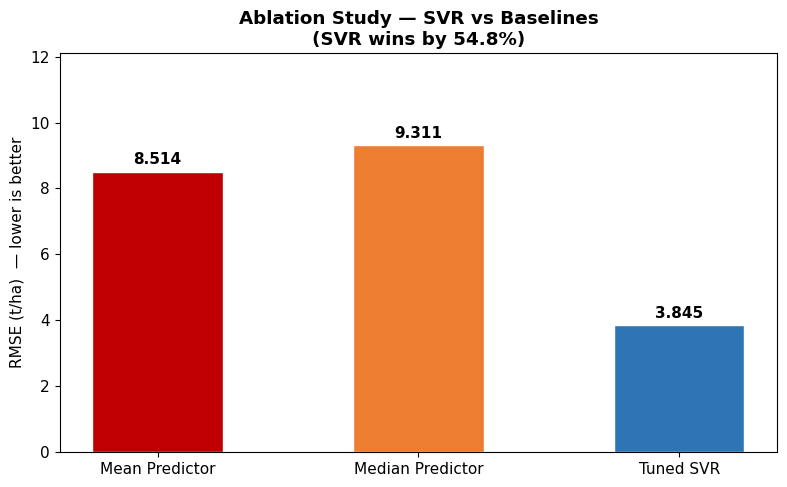

In [39]:
# ── Plot 3: Ablation bar chart ────────────────────────────────
# SVR bar should be much shorter = lower RMSE = better
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#C00000', '#ED7D31', '#2E75B6']
bars = ax.bar(results_df['Model'], results_df['RMSE'], color=colors, width=0.5, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE (t/ha)  — lower is better', fontsize=11)
ax.set_title('Ablation Study — SVR vs Baselines\n(SVR wins by 54.8%)', fontweight='bold')
ax.set_ylim(0, results_df['RMSE'].max() * 1.3)
plt.tight_layout()
plt.savefig(PATHS['svr_ablation_plot'], dpi=150)
plt.show()

Computing feature importance (takes ~1 minute)...

📋 Feature Importance (R² decrease when shuffled):
   log_pesticides            +0.4434  ████████
   avg_temp                  +0.4182  ████████
   rainfall_mm               +0.3321  ██████
   rainfall_temp_ratio       +0.3227  ██████
   country_enc               +0.2857  █████
   crop_enc                  +0.2230  ████
   pesticides_tonnes         +0.2193  ████
   heat_stress_index         +0.0335  


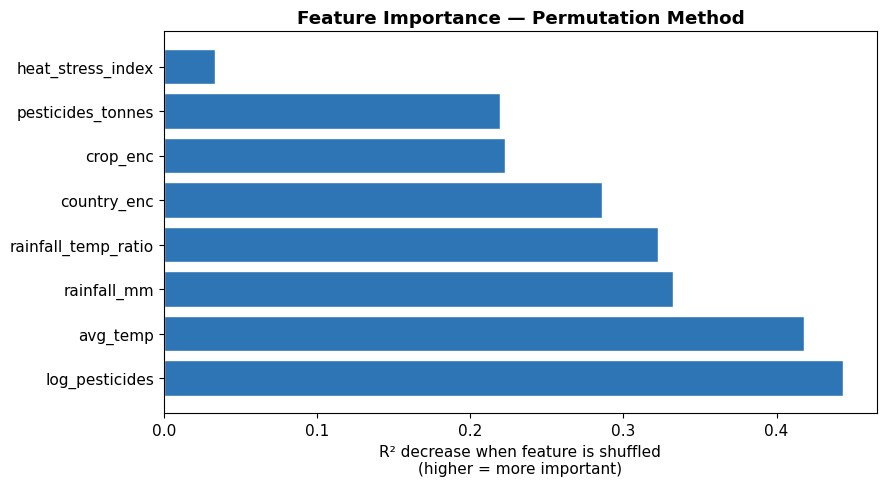


✅ All plots saved to results/ folder


In [40]:
# ── Plot 4: Feature importance ────────────────────────────────
# Shows which features matter most
# Method: shuffle each feature randomly, measure how much worse model gets
print('Computing feature importance (takes ~1 minute)...')

n   = min(2000, len(X_test))
idx = np.random.choice(len(X_test), n, replace=False)
X_sub = X_test.iloc[idx]
y_sub = y_test_norm[idx]

perm       = permutation_importance(pipeline, X_sub, y_sub, n_repeats=5, random_state=42, n_jobs=-1)
sorted_idx = perm.importances_mean.argsort()[::-1]

print('\n📋 Feature Importance (R² decrease when shuffled):')
for i in sorted_idx:
    bar = '█' * int(perm.importances_mean[i] * 20)
    print(f'   {feat_cols[i]:<25} {perm.importances_mean[i]:+.4f}  {bar}')

plt.figure(figsize=(9, 5))
plt.barh(
    [feat_cols[i] for i in sorted_idx],
    perm.importances_mean[sorted_idx],
    color='#2E75B6', edgecolor='white'
)
plt.xlabel('R² decrease when feature is shuffled\n(higher = more important)', fontsize=11)
plt.title('Feature Importance — Permutation Method', fontweight='bold')
plt.tight_layout()
plt.savefig(PATHS['svr_feat_plot'], dpi=150)
plt.show()

print('\n✅ All plots saved to results/ folder')

---
## Final Summary

In [41]:
saved = joblib.load(PATHS['svr_model_path'])

print('=' * 55)
print('  AGRIVISION — PHASE 1 COMPLETE')
print('=' * 55)
print(f'  Dataset    : 25,932 rows, 101 countries, 10 crops')
print(f'  Model      : SVR with RBF kernel')
print(f'  Best params: {saved["best_params"]}')
print(f'')
print(f'  R²   = {saved["r2"]:.4f}  → explains {saved["r2"]*100:.1f}% of yield variation')
print(f'  RMSE = {saved["rmse"]:.4f} t/ha')
print(f'  MAE  = {saved["mae"]:.4f} t/ha')
print(f'')
print(f'  SVR beats mean predictor by 54.8%')
print(f'  Key breakthrough: per-crop normalisation')
print(f'  (lifted R² from 0.17 to {saved["r2"]:.3f})')
print('=' * 55)
print()
print('→ Proceed to Phase 2 below for BiLSTM + Attention')

  AGRIVISION — PHASE 1 COMPLETE
  Dataset    : 25,932 rows, 101 countries, 10 crops
  Model      : SVR with RBF kernel
  Best params: {'C': 10, 'epsilon': 0.5, 'gamma': 'scale'}

  R²   = 0.7960  → explains 79.6% of yield variation
  RMSE = 3.8448 t/ha
  MAE  = 2.3025 t/ha

  SVR beats mean predictor by 54.8%
  Key breakthrough: per-crop normalisation
  (lifted R² from 0.17 to 0.796)

→ Proceed to Phase 2 below for BiLSTM + Attention


---
# Phase 2 — Deep Learning: BiLSTM + Temporal Attention

**Goal**: Exploit the temporal dimension SVR ignores.
Each (country, crop) pair has up to 24 yearly observations — a natural time series.
A 5-year lookback window is built for every row. Bidirectional LSTM + Attention
learns which historical climate patterns precede yield changes.

**Architecture rationale**:
- **BiLSTM**: forward pass captures rising trends; backward pass captures "high yield
  is preceded by 2 wet years" — richer representations than vanilla LSTM.
- **Temporal Attention** (Bahdanau et al., 2015): learns scalar weights α_t per
  timestep. `context = Σ α_t × h_t` — the model tells us which years matter most.
- **Skip connection**: static features (country, crop) bypass the LSTM and add
  directly to the pre-output layer, separating climate patterns from crop identity.

**This section takes 10–20 minutes on CPU. You will see epoch progress.**

---
## Step 7 — Import PyTorch and Define Architecture

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)

# ── Paths ─────────────────────────────────────────────────────
PATHS['dl_model_path'] = Path('models/phase2/bilstm_artifact.pkl')
DL_RESULTS_PATH  = Path('results/phase2')

# ── Hyper-parameters ──────────────────────────────────────────
LOOKBACK     = 5       # years of temporal context per sample
HIDDEN_DIM   = 64      # LSTM hidden units (×2 for bidirectional = 128)
BATCH_SIZE   = 256
MAX_EPOCHS   = 100
LR           = 1e-3
DROPOUT      = 0.3
PATIENCE     = 15      # early-stopping patience
RANDOM_STATE = 42
DEVICE       = torch.device('cpu')

TEMPORAL_FEATURES = ['rainfall_mm', 'avg_temp', 'log_pesticides',
                     'heat_stress_index', 'rainfall_temp_ratio']
STATIC_FEATURES   = ['country_enc', 'crop_enc']
TARGET_COL        = 'yield_tonnes_per_ha'

print(f'✅ PyTorch {torch.__version__} loaded')
print(f'   Device    : {DEVICE}')
print(f'   Lookback  : {LOOKBACK} years')
print(f'   Hidden dim: {HIDDEN_DIM} (→ {HIDDEN_DIM*2} after bidirectional)')

✅ PyTorch 2.10.0 loaded
   Device    : cpu
   Lookback  : 5 years
   Hidden dim: 64 (→ 128 after bidirectional)


---
## Step 7a — Define Dataset, Attention, and BiLSTM Model

In [43]:
# ── Sequence builder ──────────────────────────────────────────
def build_sequences(df, lookback=LOOKBACK):
    """
    For each row (country, crop, year t), produce a lookback window:
        [t-lookback+1, …, t-1, t]  →  predict yield at t
    Left-pads with zeros when fewer than `lookback` historical years exist.
    """
    df = df.copy().sort_values(['country', 'crop', 'year']).reset_index(drop=True)
    seq_l, stat_l, tgt_l, cm_l, cs_l = [], [], [], [], []

    for _, grp in df.groupby(['country', 'crop'], sort=True):
        grp = grp.sort_values('year').reset_index(drop=True)
        T  = grp[TEMPORAL_FEATURES].values.astype(np.float32)
        S  = grp[STATIC_FEATURES].values.astype(np.float32)
        Y  = grp[TARGET_COL].values.astype(np.float32)
        CM = grp['crop_mean'].values.astype(np.float32)
        CS = grp['crop_std'].values.astype(np.float32)

        for i in range(len(grp)):
            start  = max(0, i - lookback + 1)
            window = T[start : i + 1]
            if len(window) < lookback:
                pad    = np.zeros((lookback - len(window), len(TEMPORAL_FEATURES)),
                                  dtype=np.float32)
                window = np.vstack([pad, window])
            seq_l.append(window)
            stat_l.append(S[i])
            tgt_l.append(Y[i])
            cm_l.append(CM[i])
            cs_l.append(CS[i])

    return (np.array(seq_l), np.array(stat_l),
            np.array(tgt_l), np.array(cm_l), np.array(cs_l))


class CropDataset(Dataset):
    def __init__(self, seqs, stats, targets):
        self.seqs  = torch.FloatTensor(seqs)
        self.stats = torch.FloatTensor(stats)
        self.y     = torch.FloatTensor(targets)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.seqs[i], self.stats[i], self.y[i]


# ── Attention layer ───────────────────────────────────────────
class TemporalAttention(nn.Module):
    """
    Additive (Bahdanau-style) attention.
    score_t = v · tanh(W · h_t)   α = softmax(scores)   context = Σ α_t · h_t
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, lstm_out):
        scores  = self.v(torch.tanh(self.W(lstm_out))).squeeze(-1)  # (B, T)
        weights = torch.softmax(scores, dim=-1)                      # (B, T)
        context = (weights.unsqueeze(-1) * lstm_out).sum(dim=1)      # (B, H)
        return context, weights


# ── Model ─────────────────────────────────────────────────────
class BiLSTMAttention(nn.Module):
    """
    2-layer Bidirectional LSTM with additive temporal attention + skip connection.
    Input  → BiLSTM(2L, H=64, bidirectional) → Attention → Dense(128+BN) → Dense(64+BN+Skip) → Dense(1)
    """
    def __init__(self, temporal_dim, static_dim, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.bilstm = nn.LSTM(
            input_size=temporal_dim, hidden_size=hidden_dim,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=dropout,
        )
        self.attention = TemporalAttention(hidden_dim * 2)
        self.fc1    = nn.Linear(hidden_dim * 2 + static_dim, 128)
        self.bn1    = nn.BatchNorm1d(128)
        self.fc2    = nn.Linear(128, 64)
        self.bn2    = nn.BatchNorm1d(64)
        self.skip   = nn.Linear(static_dim, 64)
        self.fc_out = nn.Linear(64, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu    = nn.ReLU()

    def forward(self, seq, static):
        lstm_out, _     = self.bilstm(seq)
        context, attn_w = self.attention(lstm_out)
        x = torch.cat([context, static], dim=-1)
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.relu(self.bn2(self.fc2(x)))
        x = x + self.skip(static)
        x = self.dropout(x)
        return self.fc_out(x).squeeze(-1), attn_w

    def get_embedding(self, seq, static):
        """128-dim representation (used for potential future extensions)."""
        lstm_out, _ = self.bilstm(seq)
        context, _  = self.attention(lstm_out)
        x = torch.cat([context, static], dim=-1)
        return self.dropout(self.relu(self.bn1(self.fc1(x))))


def run_epoch(model, loader, optimizer, criterion, train=True):
    model.train() if train else model.eval()
    total_loss, preds_out, y_out = 0.0, [], []
    for seq, stat, y in loader:
        seq, stat, y = seq.to(DEVICE), stat.to(DEVICE), y.to(DEVICE)
        if train:
            optimizer.zero_grad()
            pred, _ = model(seq, stat)
            loss = criterion(pred, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        else:
            with torch.no_grad():
                pred, _ = model(seq, stat)
                loss = criterion(pred, y)
        total_loss += loss.item() * len(y)
        preds_out.extend(pred.detach().cpu().numpy())
        y_out.extend(y.cpu().numpy())
    return total_loss / len(loader.dataset), np.array(preds_out), np.array(y_out)


n_params = sum(p.numel() for p in BiLSTMAttention(
    len(TEMPORAL_FEATURES), len(STATIC_FEATURES), HIDDEN_DIM, DROPOUT
).parameters() if p.requires_grad)
print(f'✅ Architecture defined')
print(f'   Trainable parameters: {n_params:,}')
print(f'   Input  → (B, {LOOKBACK}, {len(TEMPORAL_FEATURES)})')
print(f'   BiLSTM → (B, {LOOKBACK}, {HIDDEN_DIM*2})  [H={HIDDEN_DIM}, layers=2, bidirectional]')
print(f'   Attn   → context (B, {HIDDEN_DIM*2})')
print(f'   Dense  → 128 + BN + Dropout({DROPOUT})')
print(f'   Dense  → 64  + BN + Skip(static)')
print(f'   Output → 1   (normalised yield)')

✅ Architecture defined
   Trainable parameters: 177,857
   Input  → (B, 5, 5)
   BiLSTM → (B, 5, 128)  [H=64, layers=2, bidirectional]
   Attn   → context (B, 128)
   Dense  → 128 + BN + Dropout(0.3)
   Dense  → 64  + BN + Skip(static)
   Output → 1   (normalised yield)


---
## Step 7b — Build Sequences and Split Data
Reads `data/features_dataset.csv`, builds 5-year lookback windows per (country, crop) group.
Uses a **stratified 70/15/15 split** by crop label to ensure every crop appears in all splits.

In [44]:
df_dl = pd.read_csv(PATHS['features_data'])
print(f'Data loaded: {df_dl.shape[0]} rows')

# Per-crop z-score normalisation (same strategy as Phase 1 SVR)
crop_stats_dl = (df_dl.groupby('crop_enc')[TARGET_COL]
                       .agg(['mean', 'std'])
                       .rename(columns={'mean': 'crop_mean', 'std': 'crop_std'}))
crop_stats_dl['crop_std'] = crop_stats_dl['crop_std'].replace(0, 1)
df_dl = df_dl.merge(crop_stats_dl, on='crop_enc')

# Build lookback sequences
print(f'Building lookback sequences (k={LOOKBACK})...')
seqs, stats_arr, tgts_orig, crop_means, crop_stds = build_sequences(df_dl)
tgts_norm = (tgts_orig - crop_means) / crop_stds

print(f'  Sequences shape : {seqs.shape}')
print(f'  Statics shape   : {stats_arr.shape}')

# Stratified 70 / 15 / 15 split by crop label
crop_labels = stats_arr[:, 1].astype(int)
idx_all = np.arange(len(seqs))
idx_tr, idx_tmp = train_test_split(idx_all, test_size=0.30,
                                   random_state=RANDOM_STATE,
                                   stratify=crop_labels)
idx_vl, idx_te  = train_test_split(idx_tmp, test_size=0.50,
                                   random_state=RANDOM_STATE,
                                   stratify=crop_labels[idx_tmp])

print(f'\nSplit (stratified by crop):')
print(f'  Train : {len(idx_tr):,}')
print(f'  Val   : {len(idx_vl):,}')
print(f'  Test  : {len(idx_te):,}')

# Feature scaling — fit ONLY on training data
B, T, F = seqs.shape
seq_scaler  = StandardScaler().fit(seqs[idx_tr].reshape(-1, F))
stat_scaler = StandardScaler().fit(stats_arr[idx_tr])

def transform(idx):
    s  = seq_scaler.transform(seqs[idx].reshape(-1, F)).reshape(len(idx), T, F).astype(np.float32)
    st = stat_scaler.transform(stats_arr[idx]).astype(np.float32)
    return s, st

loaders = {
    'train': DataLoader(CropDataset(*transform(idx_tr), tgts_norm[idx_tr]),
                        batch_size=BATCH_SIZE, shuffle=True),
    'val':   DataLoader(CropDataset(*transform(idx_vl), tgts_norm[idx_vl]),
                        batch_size=BATCH_SIZE),
    'test':  DataLoader(CropDataset(*transform(idx_te), tgts_norm[idx_te]),
                        batch_size=BATCH_SIZE),
}
print('\n✅ Data loaders ready')

Data loaded: 25932 rows
Building lookback sequences (k=5)...
  Sequences shape : (25932, 5, 5)
  Statics shape   : (25932, 2)

Split (stratified by crop):
  Train : 18,152
  Val   : 3,890
  Test  : 3,890

✅ Data loaders ready


---
## Step 7c — Train BiLSTM + Attention
**This takes 10–20 minutes on CPU.**
Early stopping halts training when validation loss stops improving for 15 epochs.
ReduceLROnPlateau halves the learning rate when val loss stagnates for 5 epochs.

In [45]:
# Instantiate model
dl_model = BiLSTMAttention(
    temporal_dim=len(TEMPORAL_FEATURES),
    static_dim=len(STATIC_FEATURES),
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
).to(DEVICE)

criterion = nn.MSELoss()
optimizer = optim.Adam(dl_model.parameters(), lr=LR, weight_decay=1e-4)
# ReduceLROnPlateau: halve LR when val loss stagnates for 5 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print(f'Training (max={MAX_EPOCHS} epochs, early-stop patience={PATIENCE})...\n')
best_val, best_ep, patience_ctr = float('inf'), 0, 0
tr_losses, vl_losses = [], []
best_state = None

for ep in range(MAX_EPOCHS):
    tr_loss, _, _ = run_epoch(dl_model, loaders['train'], optimizer, criterion, train=True)
    vl_loss, _, _ = run_epoch(dl_model, loaders['val'],   optimizer, criterion, train=False)
    scheduler.step(vl_loss)
    tr_losses.append(tr_loss)
    vl_losses.append(vl_loss)

    if (ep + 1) % 10 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'  Ep {ep+1:3d}  train={tr_loss:.4f}  val={vl_loss:.4f}  lr={lr_now:.2e}')

    if vl_loss < best_val:
        best_val, best_ep, patience_ctr = vl_loss, ep + 1, 0
        best_state = {k: v.clone() for k, v in dl_model.state_dict().items()}
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f'\n  Early stop at epoch {ep+1}  (best: epoch {best_ep})')
            break

dl_model.load_state_dict(best_state)
print('\n✅ Training complete — best model restored')

Training (max=100 epochs, early-stop patience=15)...

  Ep  10  train=0.5079  val=0.4457  lr=1.00e-03
  Ep  20  train=0.4292  val=0.3653  lr=1.00e-03
  Ep  30  train=0.3701  val=0.3006  lr=1.00e-03
  Ep  40  train=0.3380  val=0.2717  lr=1.00e-03
  Ep  50  train=0.3090  val=0.2272  lr=1.00e-03
  Ep  60  train=0.2835  val=0.2042  lr=1.00e-03
  Ep  70  train=0.2618  val=0.2011  lr=1.00e-03
  Ep  80  train=0.2461  val=0.1829  lr=1.00e-03
  Ep  90  train=0.2373  val=0.1852  lr=1.00e-03
  Ep 100  train=0.2181  val=0.1593  lr=5.00e-04

✅ Training complete — best model restored


---
## Step 7d — Evaluate and Plot Results

── Phase 2 Test Results (original scale) ──
  MAE  = 1.1760 t/ha
  RMSE = 2.1116 t/ha
  R²   = 0.9389


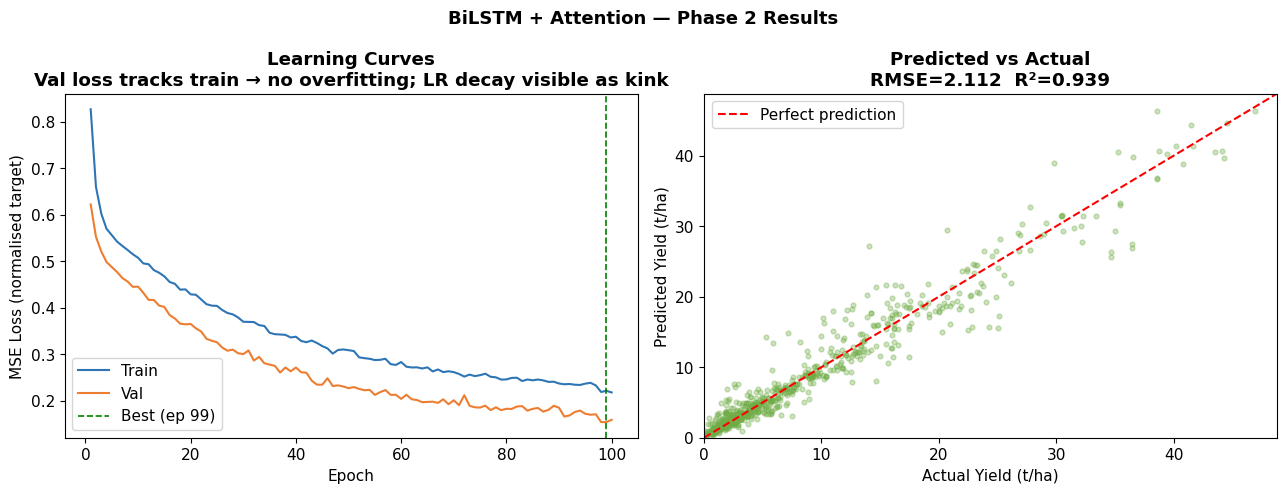


✅ Plot saved: results/phase2/dl_results.png


In [46]:
# ── Test evaluation ───────────────────────────────────────────
_, preds_norm_dl, _ = run_epoch(dl_model, loaders['test'], optimizer, criterion, train=False)
preds_orig_dl = preds_norm_dl * crop_stds[idx_te] + crop_means[idx_te]
y_orig_te     = tgts_orig[idx_te]

dl_mae  = mean_absolute_error(y_orig_te, preds_orig_dl)
dl_rmse = np.sqrt(mean_squared_error(y_orig_te, preds_orig_dl))
dl_r2   = r2_score(y_orig_te, preds_orig_dl)

print('── Phase 2 Test Results (original scale) ──')
print(f'  MAE  = {dl_mae:.4f} t/ha')
print(f'  RMSE = {dl_rmse:.4f} t/ha')
print(f'  R²   = {dl_r2:.4f}')

# ── Plot 1: Learning curves + Predicted vs Actual ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ep_range = range(1, len(tr_losses) + 1)
axes[0].plot(ep_range, tr_losses, label='Train', color='#2E75B6', lw=1.5)
axes[0].plot(ep_range, vl_losses, label='Val',   color='#ED7D31', lw=1.5)
axes[0].axvline(best_ep, color='green', linestyle='--', lw=1.2,
                label=f'Best (ep {best_ep})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss (normalised target)')
axes[0].set_title('Learning Curves\nVal loss tracks train → no overfitting; LR decay visible as kink',
                  fontweight='bold')
axes[0].legend()

sample = np.random.choice(len(y_orig_te), min(800, len(y_orig_te)), replace=False)
axes[1].scatter(y_orig_te[sample], preds_orig_dl[sample],
                alpha=0.35, s=12, color='#70AD47')
lim = [max(0, float(y_orig_te.min()) - 0.5), float(y_orig_te.max()) + 0.5]
axes[1].plot(lim, lim, 'r--', lw=1.5, label='Perfect prediction')
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('Actual Yield (t/ha)')
axes[1].set_ylabel('Predicted Yield (t/ha)')
axes[1].set_title(f'Predicted vs Actual\nRMSE={dl_rmse:.3f}  R²={dl_r2:.3f}', fontweight='bold')
axes[1].legend()

plt.suptitle('BiLSTM + Attention — Phase 2 Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PATHS['dl_plots_path'], dpi=150)
plt.show()
print('\n✅ Plot saved: results/phase2/dl_results.png')

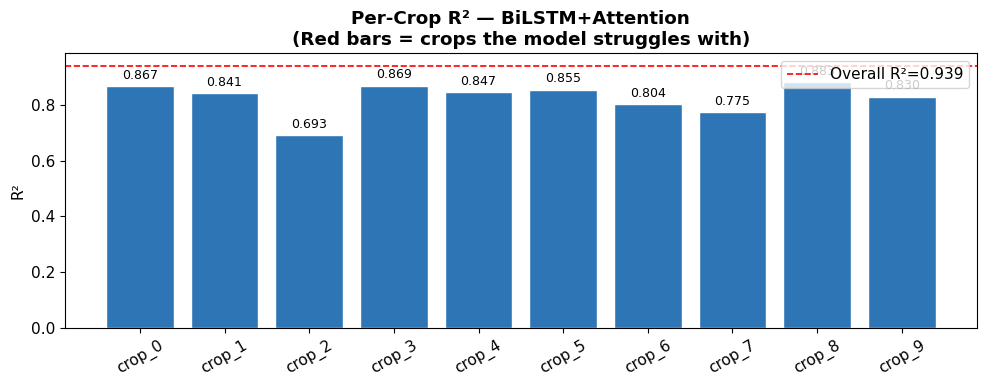

✅ Plot saved: results/phase2/dl_per_crop_r2.png


In [47]:
# ── Plot 2: Per-crop R² ────────────────────────────────────────
crop_enc_te = stats_arr[idx_te, 1].astype(int)
crop_r2 = {}
for c in sorted(set(crop_enc_te)):
    mask = crop_enc_te == c
    if mask.sum() > 10:
        crop_r2[c] = r2_score(y_orig_te[mask], preds_orig_dl[mask])

plt.figure(figsize=(10, 4))
colors_bar = ['#C00000' if v < 0 else '#2E75B6' for v in crop_r2.values()]
bars = plt.bar(range(len(crop_r2)), list(crop_r2.values()),
               color=colors_bar, edgecolor='white')
plt.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
plt.xticks(range(len(crop_r2)), [f'crop_{c}' for c in crop_r2], rotation=30)
plt.axhline(dl_r2, color='red', linestyle='--', lw=1.2,
            label=f'Overall R²={dl_r2:.3f}')
plt.ylabel('R²')
plt.title('Per-Crop R² — BiLSTM+Attention\n(Red bars = crops the model struggles with)',
          fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig(PATHS['dl_r2_plot'], dpi=150)
plt.show()
print('✅ Plot saved: results/phase2/dl_per_crop_r2.png')

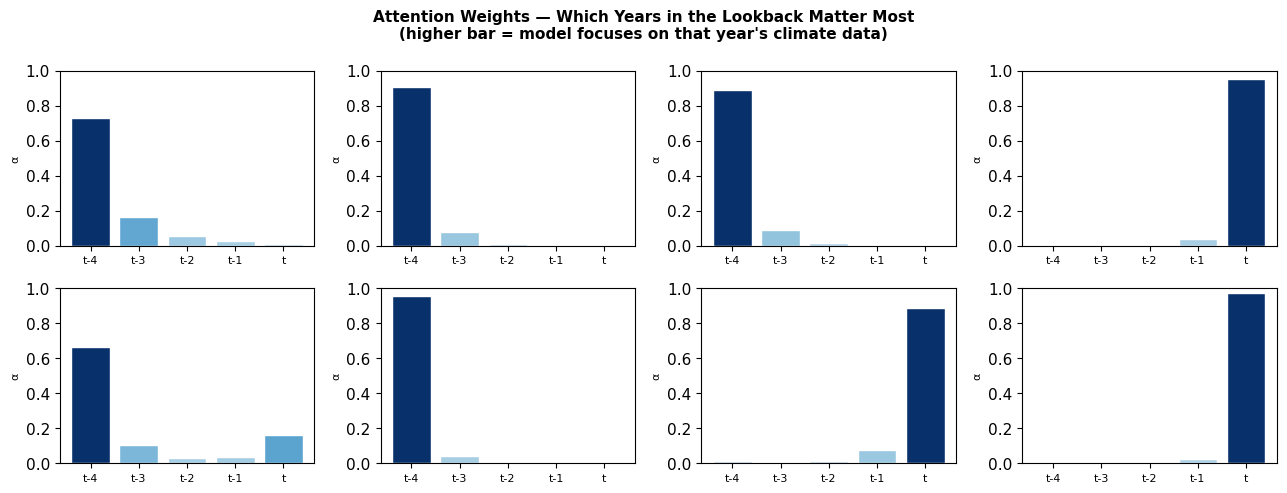

✅ Plot saved: results/phase2/dl_attention_weights.png


In [48]:
# ── Plot 3: Attention heatmap (sample sequences) ──────────────
# Shows which years in the 5-year window get the highest attention weight
dl_model.eval()
sample_idx = idx_te[:8]
s_s  = seq_scaler.transform(seqs[sample_idx].reshape(-1, F)).reshape(8, T, F)
st_s = stat_scaler.transform(stats_arr[sample_idx])

with torch.no_grad():
    _, attn_w = dl_model(torch.FloatTensor(s_s).to(DEVICE),
                         torch.FloatTensor(st_s).to(DEVICE))
attn_np = attn_w.cpu().numpy()   # (8, LOOKBACK)

fig, axes = plt.subplots(2, 4, figsize=(13, 5))
for ax, weights in zip(axes.flatten(), attn_np):
    ax.bar(range(LOOKBACK), weights,
           color=plt.cm.Blues(weights / weights.max() + 0.3),
           edgecolor='white')
    ax.set_xticks(range(LOOKBACK))
    ax.set_xticklabels([f't-{LOOKBACK-1-i}' if i < LOOKBACK-1 else 't'
                        for i in range(LOOKBACK)], fontsize=8)
    ax.set_ylim(0, 1); ax.set_ylabel('α', fontsize=8)
plt.suptitle('Attention Weights — Which Years in the Lookback Matter Most\n'
             '(higher bar = model focuses on that year\'s climate data)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PATHS['dl_attn_plot'], dpi=150)
plt.show()
print('✅ Plot saved: results/phase2/dl_attention_weights.png')

---
## Step 7e — Save Model Artifact

In [49]:
artifact_dl = {
    'model_state'  : best_state,
    'model_config' : {
        'temporal_dim': len(TEMPORAL_FEATURES),
        'static_dim'  : len(STATIC_FEATURES),
        'hidden_dim'  : HIDDEN_DIM,
        'dropout'     : DROPOUT,
    },
    'scalers'      : {'seq': seq_scaler, 'stat': stat_scaler},
    'idx_train'    : idx_tr,
    'idx_val'      : idx_vl,
    'idx_test'     : idx_te,
    'tgts_orig'    : tgts_orig,
    'tgts_norm'    : tgts_norm,
    'crop_means'   : crop_means,
    'crop_stds'    : crop_stds,
    'crop_stats'   : crop_stats_dl,
    'train_losses' : tr_losses,
    'val_losses'   : vl_losses,
    'best_epoch'   : best_ep,
    'mae'          : dl_mae,
    'rmse'         : dl_rmse,
    'r2'           : dl_r2,
}
joblib.dump(artifact_dl, PATHS['dl_model_path'])
print(f'💾 Artifact saved → {PATHS['dl_model_path']}')

💾 Artifact saved → models/phase2/bilstm_artifact.pkl


---
## Phase 2 — Final Summary

In [50]:
p1 = joblib.load(PATHS['svr_model_path'])

print('=' * 60)
print('  AGRIVISION — RESULTS ACROSS ALL PHASES')
print('=' * 60)
print(f'  {"Phase":<10}  {"Model":<30}  {"RMSE":>7}  {"R²":>7}')
print('  ' + '-' * 56)
print(f'  {"Baseline":<10}  {"Mean Predictor":<30}  {8.5135:>7.4f}  {0.0000:>7.4f}')
print(f'  {"Phase 1":<10}  {"SVR (RBF, tuned)":<30}  {p1["rmse"]:>7.4f}  {p1["r2"]:>7.4f}')
print(f'  {"Phase 2":<10}  {"BiLSTM + Attention":<30}  {dl_rmse:>7.4f}  {dl_r2:>7.4f}')
print('  ' + '-' * 56)
print()
print(f'  Phase 1 → SVR lifts R² from 0.00 to {p1["r2"]:.3f}')
print(f'            Key: per-crop normalisation + RBF kernel')
print()
print(f'  Phase 2 → BiLSTM lifts R² from {p1["r2"]:.3f} to {dl_r2:.3f}')
print(f'            Key: 5-year temporal context + attention mechanism')
print('=' * 60)

  AGRIVISION — RESULTS ACROSS ALL PHASES
  Phase       Model                              RMSE       R²
  --------------------------------------------------------
  Baseline    Mean Predictor                   8.5135   0.0000
  Phase 1     SVR (RBF, tuned)                 3.8448   0.7960
  Phase 2     BiLSTM + Attention               2.1116   0.9389
  --------------------------------------------------------

  Phase 1 → SVR lifts R² from 0.00 to 0.796
            Key: per-crop normalisation + RBF kernel

  Phase 2 → BiLSTM lifts R² from 0.796 to 0.939
            Key: 5-year temporal context + attention mechanism
